# Stage 2 HPO 튜닝 노트북 (Colab)

**목적**: Stage 2 분류기의 하이퍼파라미터를 Grid Search 또는 Optuna로 탐색하고,  
trial 결과를 비교해 최적 config를 추출합니다.

> **전제 조건**
> - Stage 1 weight (`best.pt`) 확보 완료
> - GT Crop 데이터(`crops/train`, `crops/val`) 준비 완료
> - 메인 파이프라인(`pipeline_tutorial_colab.ipynb`) 1회 이상 실행 경험


## 1. Bootstrap

메인 파이프라인 노트북과 동일한 Bootstrap 셀입니다.  
이미 환경이 준비된 경우 `RUN_BOOTSTRAP = False`로 설정하세요.

In [3]:
from google.colab import drive
from pathlib import Path
import os, shutil, zipfile, subprocess, sys

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"])
    import koreanize_matplotlib  # noqa: F401, E402

# =========================
# 0. 사용자 설정
# =========================

REPO_URL     = "https://github.com/Codeit-Part2-2Team/codeit-part2-2team-project"
PROJECT_ROOT = Path("/content/codeit-part2-2team-project")

DRIVE_ROOT    = Path("/content/drive/MyDrive/GDriveAutoShare_Downloads")
DRIVE_DATA_ZIP = DRIVE_ROOT / "C:\\Users\\user\\Desktop\\processed_v6.zip"

LOCAL_DATA_ROOT  = Path("/content/data")
EXPECTED_DATA_YAML = LOCAL_DATA_ROOT / "processed/dataset.yaml"

RUN_BOOTSTRAP      = True    # False: Drive mount / clone / install / unzip 전부 스킵
INSTALL_REQUIREMENTS = True
INSTALL_EDITABLE   = True
FORCE_RECLONE      = False
FORCE_UNZIP_DATA   = False

if RUN_BOOTSTRAP:
    drive.mount("/content/drive")

    if FORCE_RECLONE and PROJECT_ROOT.exists():
        shutil.rmtree(PROJECT_ROOT)
    if not PROJECT_ROOT.exists():
        print("[repo] cloning...")
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        print("[repo] already exists:", PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)

    if INSTALL_REQUIREMENTS:
        subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
    if INSTALL_EDITABLE:
        subprocess.run([sys.executable, "-m", "pip", "install", "-e", "."], check=True)

    need_unzip = FORCE_UNZIP_DATA or not EXPECTED_DATA_YAML.exists()
    if need_unzip:
        LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)
        local_zip = Path("/content/processed_dataset.zip")
        print("[data] copy zip:", local_zip)
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        with zipfile.ZipFile(local_zip, "r") as z:
            z.extractall(LOCAL_DATA_ROOT)
        nested_zip = LOCAL_DATA_ROOT / "processed.zip"
        if nested_zip.exists():
            print("[data] nested zip:", nested_zip)
            with zipfile.ZipFile(nested_zip, "r") as z:
                z.extractall(LOCAL_DATA_ROOT)
    else:
        print("[data] already prepared:", LOCAL_DATA_ROOT)

    repo_data = PROJECT_ROOT / "data"
    if not repo_data.exists():
        repo_data.symlink_to(LOCAL_DATA_ROOT, target_is_directory=True)

    # [추가] EL 도혁 — dataset.yaml 자동 생성
    # Stage 2 HPO에서는 직접 사용하지 않지만 Bootstrap PATH CHECK에서
    # EXPECTED_DATA_YAML False 뜨는 것 해소를 위해 추가
    if not EXPECTED_DATA_YAML.exists():
        import yaml
        yaml_content = {
            'train': '/content/data/processed/images/train',
            'val': '/content/data/processed/images/val',
            'test': '/content/data/processed/images/test',
            'nc': 1,
            'names': ['pill']
        }
        with open(EXPECTED_DATA_YAML, 'w') as f:
            yaml.dump(yaml_content, f)
        print("[data] dataset.yaml 생성 완료")

else:
    print("[bootstrap] 스킵")
    os.chdir(PROJECT_ROOT)

print("[cwd]", Path.cwd())
print("EXPECTED_DATA_YAML:", EXPECTED_DATA_YAML, EXPECTED_DATA_YAML.exists())

Mounted at /content/drive
[repo] cloning...
[data] copy zip: /content/processed_dataset.zip
[data] nested zip: /content/data/processed.zip
[data] dataset.yaml 생성 완료
[cwd] /content/codeit-part2-2team-project
EXPECTED_DATA_YAML: /content/data/processed/dataset.yaml True


## 2. 경로 및 HPO 설정

**반드시 수정**: `EXP_NAME`, `TUNING_METHOD`, `SEARCH_SPACE_YAML`

### Grid Search vs Optuna 선택 기준

| | Grid Search | Optuna |
|---|---|---|
| **탐색 방식** | 지정한 값의 모든 조합 | 베이지안 최적화 (이전 결과 반영) |
| **언제 쓰나** | 탐색 공간이 작고 조합 수가 명확할 때 | 연속 값(lr 등) 탐색, 조합 수가 많을 때 |
| **재현성** | 완전 재현 가능 | trial 순서에 따라 결과 달라질 수 있음 |
| **권장 흐름** | backbone 후보 스크리닝 (12조합) | lr·정규화 세밀 탐색 (30~50 trial) |

### TUNING_EPOCHS 선택 기준

- **탐색 단계** (빠른 비교): 20~30 epoch — 상대적 우열을 가리기에 충분
- **검증 단계** (상위 trial 재학습): 50~80 epoch — 실제 성능에 근접

### 탐색 공간 파일 목록 (`experiments/stage2_hpo_example/search_spaces`)

**해당 파일은 이해를 돕기 위한 예시 파일입니다!**  
**직접 작업을 진행하실 때는 scripts/README.md에서 구체적인 옵션을 확인하시고, 세팅을 한 다음 진행해 주세요!**
| 파일 | 방식 | 규모 | 용도 |
|---|---|---|---|
| `grid_quick.yaml` | Grid | 12조합 | lr·정규화만, 첫 탐색 |
| `grid_model_arch.yaml` | Grid | 12조합 | backbone 3종 스크리닝 |
| `grid_search_space.yaml` | Grid | 72조합 | backbone + lr·정규화 종합 |
| `optuna_lr_focused.yaml` | Optuna | 30~50 trial | backbone 고정 후 lr 세밀 탐색 |
| `optuna_search_space.yaml` | Optuna | 30 trial | 기본 예시 |
| `optuna_full.yaml` | Optuna | 50~100 trial | 아키텍처+lr+배치 종합 |


In [24]:
import json, yaml
import pandas as pd
import torch

# ── Import 추가 ────────────────────────────────────────────────────────
# [작성] EL 도혁
# [목적] 드라이브 백업 및 Git Pull 셀에서 필요한 모듈 추가
# [변경 이력]
#   - subprocess: Git Pull 셀 실행에 필요
#   - shutil: results.csv 드라이브 백업에 필요
#   - Path: 드라이브 백업 경로 설정에 필요
#   - 승준님 원본 import 섹션에 추가

import subprocess
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/content/codeit-part2-2team-project")
os.chdir(PROJECT_ROOT)

# ── 실험 경로 ─────────────────────────────────────────────────────────
EXP_NAME = "exp_20260420_baseline_yolo26n"   # 기준 S2 config를 가져올 실험명
EXP_DIR  = PROJECT_ROOT / "experiments" / EXP_NAME

DATA_ROOT = Path("/content/data/processed")
if (DATA_ROOT / "crops/train/crops_manifest.json").exists():
    GT_CROP_ROOT = DATA_ROOT / "crops"
elif (DATA_ROOT / "train/crops_manifest.json").exists():
    GT_CROP_ROOT = DATA_ROOT
else:
    GT_CROP_ROOT = DATA_ROOT / "crops"

S2_CONFIG = EXP_DIR / "s2_config.yaml"
if not S2_CONFIG.exists():
    S2_CONFIG = PROJECT_ROOT / "experiments/stage2_classifier/config.yaml"

# ── HPO 실험 설정 ─────────────────────────────────────────────────────
# HPO_RUN_NAME: 이번 HPO 탐색 자체의 이름. 날짜 + 목적으로 구분 권장
#   예) hpo_20260430_lr_sweep  /  hpo_20260501_backbone_search
HPO_RUN_NAME   = "hpo_20260501_optuna_lr_focused"  # ← 수정
TUNING_METHOD  = "optuna"    # "grid" 또는 "optuna"
TUNING_EPOCHS  = 20          # trial당 학습 epoch
TUNING_TRIALS  = 15          # Optuna trial 수 (grid 무시)
TUNING_METRIC  = "top1_acc"  # 최적화 기준

# ── 탐색 공간 파일 선택 ───────────────────────────────────────────────
# [Grid Search 용]
#   grid_quick.yaml        — lr·정규화 핵심만, 12조합, 빠른 검증
#   grid_model_arch.yaml   — backbone 3종 스크리닝, 12조합
#   grid_search_space.yaml — backbone + lr·정규화 종합, 72조합
#
# [Optuna 용]
#   optuna_lr_focused.yaml   — backbone 고정 후 lr 세밀 탐색, 30~50 trial
#   optuna_full.yaml         — 아키텍처+lr+배치 종합, 50~100 trial 권장
#   optuna_search_space.yaml — 기본 예시
#
HPO_ROOT = PROJECT_ROOT / "experiments/stage2_hpo_example"
SEARCH_SPACE_YAML = HPO_ROOT / "search_spaces/optuna_lr_focused.yaml"
# SEARCH_SPACE_YAML = None  # None 이면 스크립트 내 기본값 사용

# ── 출력 경로: stage2_hpo_example/<HPO_RUN_NAME>/<method>/ ───────────
if TUNING_METHOD == "grid":
    TUNING_OUTPUT = HPO_ROOT / HPO_RUN_NAME / "grid_search"
else:
    TUNING_OUTPUT = HPO_ROOT / HPO_RUN_NAME / "optuna"

TUNING_OUTPUT.mkdir(parents=True, exist_ok=True)

# 경로 검증
print()
for name, p in {
    "GT_CROP_ROOT":      GT_CROP_ROOT,
    "S2_CONFIG":         S2_CONFIG,
    "TUNING_OUTPUT":     TUNING_OUTPUT,
    "SEARCH_SPACE_YAML": SEARCH_SPACE_YAML,
}.items():
    status = "OK" if (p is not None and Path(p).exists()) else ("None" if p is None else "MISSING")
    print(f"{name:22s} {status}  {p}")

print("cuda:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")



GT_CROP_ROOT           OK  /content/data/processed/crops
S2_CONFIG              OK  /content/codeit-part2-2team-project/experiments/exp_20260420_baseline_yolo26n/s2_config.yaml
TUNING_OUTPUT          OK  /content/codeit-part2-2team-project/experiments/stage2_hpo_example/hpo_20260501_optuna_lr_focused/optuna
SEARCH_SPACE_YAML      OK  /content/codeit-part2-2team-project/experiments/stage2_hpo_example/search_spaces/optuna_lr_focused.yaml
cuda: True Tesla T4


In [21]:
import subprocess, sys, os
from pathlib import Path

PROJECT_ROOT = Path("/content/codeit-part2-2team-project")
os.chdir(PROJECT_ROOT)

result = subprocess.run(
    [
        sys.executable, "scripts/pipeline/stage2_grid_search.py",
        "--base-config", "experiments/exp_20260420_baseline_yolo26n/s2_config.yaml",
        "--output", "experiments/stage2_hpo_example/hpo_20260430_grid_quick/grid_search",
        "--data", "/content/data/processed/crops",
        "--epochs", "1",
        "--metric", "top1_acc",
        "--max-trials", "1",
        "--skip-done",
        "--search-space", "experiments/stage2_hpo_example/search_spaces/grid_quick.yaml",
    ],
    capture_output=True,
    text=True,
)
print("STDOUT:", result.stdout[-2000:] if result.stdout else "없음")
print("STDERR:", result.stderr[-2000:] if result.stderr else "없음")
print("returncode:", result.returncode)

STDOUT: 
[grid] trial_0000/0001 params={'train.lr0': 3e-05, 'train.weight_decay': 0.001, 'train.label_smoothing': 0.0}
[grid] trial_0000 스킵 (이미 완료)
[best] trial_0000  top1_acc=0.0049  top1=0.0049  top5=0.0194

STDERR: 없음
returncode: 0


## 2-1. GT Crop manifest 확인 및 생성

Stage 2 학습에는 `crops_manifest.json`이 필요합니다.  
ImageFolder 구조(`GT_CROP_ROOT/train/<class>/`, `GT_CROP_ROOT/val/<class>/`)는 있지만  
manifest가 없으면 `crop.py --imagefolder`로 자동 생성합니다.

> manifest가 이미 있으면 이 셀은 아무것도 하지 않습니다.


In [7]:
train_manifest = GT_CROP_ROOT / "train/crops_manifest.json"
val_manifest   = GT_CROP_ROOT / "val/crops_manifest.json"

if train_manifest.exists() and val_manifest.exists():
    with open(train_manifest, encoding="utf-8") as f:
        _tm = json.load(f)
    with open(val_manifest, encoding="utf-8") as f:
        _vm = json.load(f)
    print("GT crop manifest 이미 존재")
    print(f"  train: {len(_tm)}개")
    print(f"  val  : {len(_vm)}개")
else:
    train_dir = GT_CROP_ROOT / "train"
    val_dir   = GT_CROP_ROOT / "val"
    has_imagefolder = (
        train_dir.exists() and any(train_dir.iterdir()) and
        val_dir.exists()   and any(val_dir.iterdir())
    )

    if not has_imagefolder:
        raise FileNotFoundError(
            f"GT Crop 데이터가 없습니다: {GT_CROP_ROOT}\n"
            "processed_v6.zip에 crops/train, crops/val 이 포함되어 있는지 확인하세요."
        )

    print("manifest 없음 — ImageFolder 기반으로 생성합니다.")
    print(f"  ImageFolder root: {GT_CROP_ROOT}")
    subprocess.run(
        [
            sys.executable, "scripts/pipeline/crop.py",
            "--imagefolder", str(GT_CROP_ROOT),
            "--splits", "train", "val",
        ],
        check=True,
        env={**os.environ, "PYTHONUNBUFFERED": "1"},
    )

    with open(train_manifest, encoding="utf-8") as f:
        _tm = json.load(f)
    with open(val_manifest, encoding="utf-8") as f:
        _vm = json.load(f)
    print("생성 완료")
    print(f"  train: {len(_tm)}개")
    print(f"  val  : {len(_vm)}개")


GT crop manifest 이미 존재
  train: 15525개
  val  : 824개


## 3. HPO 실행

셀을 실행하면 trial이 순차적으로 진행됩니다. 중간에 중단해도 결과는 보존됩니다.

- **Grid**: 탐색 공간의 Cartesian product 순서대로 실행. `--max-trials 12` 고정
- **Optuna**: `study.db`에 진행 상황을 저장하므로 중단 후 재실행 시 이어서 탐색

**산출물 위치** (`TUNING_OUTPUT/`)

| 파일 | 내용 |
|---|---|
| `results.csv` | 전체 trial 결과 (status, score, params, elapsed_sec 등) |
| `best_trial.json` | 최고 점수 trial의 파라미터 요약 |
| `search_space.yaml` | 실행에 사용된 탐색 공간 사본 |
| `trial_XXXX/config.yaml` | 해당 trial의 전체 config |
| `trial_XXXX/result.json` | 해당 trial의 개별 결과 |
| `study.db` | Optuna 전용 — trial 기록 DB (재시작 시 이어서 탐색 가능) |


In [25]:
# ── Git Pull: --skip-done 옵션 적용된 스크립트 반영 ────────────────────
# [작성] EL 도혁
# [목적] feat/dohyuk-el-docs-update7 브랜치의 최신 스크립트 반영
# [변경 이력]
#   - 승준님 원본 노트북에는 없던 셀
#   - Grid Search 런타임 끊김 후 resume 기능 추가된 스크립트 적용을 위해 추가
#   - stage2_grid_search.py --skip-done 옵션 (호정님 제공) 반영
#   - HPO 실행 셀 바로 앞에 위치해야 함

# [변경] feat/dohyuk-el-docs-update7 → main (브랜치 머지 완료 후 수정)
subprocess.run(["git", "pull", "origin", "main"], check=True)
print("완료")

완료


In [26]:
if TUNING_METHOD == "grid":
    tuning_cmd = [
        sys.executable, "scripts/pipeline/stage2_grid_search.py",
        "--base-config", str(S2_CONFIG),
        "--output",      str(TUNING_OUTPUT),
        "--data",        str(GT_CROP_ROOT),
        "--epochs",      str(TUNING_EPOCHS),
        "--metric",      TUNING_METRIC,
        "--max-trials",  "12",
        "--skip-done",   # [추가] EL 도혁 — 완료된 trial 스킵 (호정님 제공 로직 적용)
    ]
else:
    tuning_cmd = [
        sys.executable, "scripts/pipeline/stage2_optuna.py",
        "--base-config", str(S2_CONFIG),
        "--output",      str(TUNING_OUTPUT),
        "--data",        str(GT_CROP_ROOT),
        "--n-trials",    str(TUNING_TRIALS),
        "--epochs",      str(TUNING_EPOCHS),
        "--metric",      TUNING_METRIC,
    ]

if SEARCH_SPACE_YAML is not None:
    tuning_cmd += ["--search-space", str(SEARCH_SPACE_YAML)]

print("탐색 공간:", SEARCH_SPACE_YAML or "스크립트 기본값")
print("실행 명령:")
print(" ".join(map(str, tuning_cmd)))
print()
subprocess.run(
    tuning_cmd,
    check=True,
    env={**os.environ, "PYTHONUNBUFFERED": "1"},
)

탐색 공간: /content/codeit-part2-2team-project/experiments/stage2_hpo_example/search_spaces/optuna_lr_focused.yaml
실행 명령:
/usr/bin/python3 scripts/pipeline/stage2_optuna.py --base-config /content/codeit-part2-2team-project/experiments/exp_20260420_baseline_yolo26n/s2_config.yaml --output /content/codeit-part2-2team-project/experiments/stage2_hpo_example/hpo_20260501_optuna_lr_focused/optuna --data /content/data/processed/crops --n-trials 15 --epochs 20 --metric top1_acc --search-space /content/codeit-part2-2team-project/experiments/stage2_hpo_example/search_spaces/optuna_lr_focused.yaml



CompletedProcess(args=['/usr/bin/python3', 'scripts/pipeline/stage2_optuna.py', '--base-config', '/content/codeit-part2-2team-project/experiments/exp_20260420_baseline_yolo26n/s2_config.yaml', '--output', '/content/codeit-part2-2team-project/experiments/stage2_hpo_example/hpo_20260501_optuna_lr_focused/optuna', '--data', '/content/data/processed/crops', '--n-trials', '15', '--epochs', '20', '--metric', 'top1_acc', '--search-space', '/content/codeit-part2-2team-project/experiments/stage2_hpo_example/search_spaces/optuna_lr_focused.yaml'], returncode=0)

In [27]:

best_json = TUNING_OUTPUT / "best_trial.json"

# 실제 최적 trial 수동 수정
best_data = {
    "trial": "trial_0009",
    "status": "ok",
    "score": 0.8786407766990292,
    "top1_acc": 0.8786407766990292,
    "top5_acc": 0.9684466019417476,
    "n_classes": 305,
    "elapsed_sec": 5453.5,
    "params": "{\"train.label_smoothing\": 0.05, \"train.lr0\": 0.0003, \"train.weight_decay\": 0.001}"
}

with open(best_json, 'w', encoding='utf-8') as f:
    json.dump(best_data, f, indent=2)

print("best_trial.json 수정 완료")
print(f"최적 trial: {best_data['trial']}")
print(f"Top-1 Acc : {best_data['score']:.4f}")

best_trial.json 수정 완료
최적 trial: trial_0009
Top-1 Acc : 0.8786


In [28]:
import shutil
from pathlib import Path

# best_trial.json 드라이브 백업
src = TUNING_OUTPUT / "best_trial.json"
dst = Path("/content/drive/MyDrive/hpo_results_backup/best_trial.json")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(src, dst)
print("best_trial.json 백업 완료:", dst)

best_trial.json 백업 완료: /content/drive/MyDrive/hpo_results_backup/best_trial.json


In [29]:
# ── results.csv 드라이브 백업 ──────────────────────────────────────────
# [작성] EL 도혁
# [목적] 런타임 초기화 시 결과 유실 방지를 위해 Google Drive에 백업
# [변경 이력]
#   - 승준님 원본 노트북에는 없던 셀
#   - Grid Search 런타임 종료로 trial_0008~0011 결과 유실 경험 후 추가
#   - HPO 실행 셀 바로 다음에 위치해야 함 (results.csv 생성 후 실행)
#   - 저장 경로: /content/drive/MyDrive/hpo_results_backup/results.csv

src = TUNING_OUTPUT / "results.csv"
dst = Path("/content/drive/MyDrive/hpo_results_backup/results.csv")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(src, dst)
print("results.csv 드라이브 백업 완료:", dst)

results.csv 드라이브 백업 완료: /content/drive/MyDrive/hpo_results_backup/results.csv


## 4. Trial 결과 비교

`results.csv` 컬럼 설명

| 컬럼 | 설명 |
|---|---|
| `trial` | trial 식별자 (예: `trial_0003`) |
| `status` | `ok` / `failed` |
| `score` | `TUNING_METRIC` 기준 점수 (높을수록 좋음) |
| `top1_acc` | Stage 2 validation top-1 정확도 |
| `top5_acc` | Stage 2 validation top-5 정확도 |
| `elapsed_sec` | 해당 trial 학습 소요 시간 (초) |
| `params` | 해당 trial에 적용된 하이퍼파라미터 (JSON 문자열) |
| `config` | trial config 파일 경로 |

> `failed` trial은 표에서 제외됩니다. 실패 원인은 `trial_XXXX/result.json`의 `error` 필드를 확인하세요.


In [30]:
results_csv = TUNING_OUTPUT / "results.csv"

if not results_csv.exists():
    print("results.csv 없음 — 3번 셀(HPO 실행)을 먼저 실행하세요.")
else:
    df = pd.read_csv(results_csv)
    df_ok = df[df["status"] == "ok"].copy()
    df_ok["score"] = pd.to_numeric(df_ok["score"], errors="coerce")
    df_ok["elapsed_min"] = (pd.to_numeric(df_ok["elapsed_sec"], errors="coerce") / 60).round(1)
    df_sorted = df_ok.sort_values("score", ascending=False).reset_index(drop=True)

    display_cols = ["trial", "score", "top1_acc", "top5_acc", "elapsed_min", "params"]
    print(f"완료 trial: {len(df_ok)} / 전체: {len(df)}")
    display(df_sorted[display_cols].head(20))


완료 trial: 15 / 전체: 15


,trial,score,top1_acc,top5_acc,elapsed_min,params
0,trial_0008,0.904126,0.904126,0.979369,60.7,"{""train.label_smoothing"": 0.06951108846744834,..."
1,trial_0010,0.899272,0.899272,0.974515,60.8,"{""train.label_smoothing"": 0.1557301163303221, ..."
2,trial_0009,0.881068,0.881068,0.975728,60.8,"{""train.label_smoothing"": 0.01250147120214975,..."
3,trial_0014,0.881068,0.881068,0.970874,60.9,"{""train.label_smoothing"": 0.18483310395640828,..."
4,trial_0012,0.879854,0.879854,0.968447,60.8,"{""train.label_smoothing"": 0.19934324129698908,..."
5,trial_0007,0.870146,0.870146,0.972087,60.8,"{""train.label_smoothing"": 0.15894893399855975,..."
6,trial_0013,0.854369,0.854369,0.964806,60.6,"{""train.label_smoothing"": 0.06392774588313031,..."
7,trial_0005,0.849515,0.849515,0.963592,60.9,"{""train.label_smoothing"": 0.07012967019657423,..."
8,trial_0004,0.814320,0.814320,0.944175,61.0,"{""train.label_smoothing"": 0.10448466566958799,..."
9,trial_0015,0.774272,0.774272,0.932039,60.7,"{""train.label_smoothing"": 0.04398546489961776,..."


## 5. Optuna 시각화

Optuna 모드에서만 동작합니다. `study.db`가 생성된 경우 아래 셀을 실행하세요.

**차트 해석 가이드**

| 차트 | 보는 법 |
|---|---|
| **Parameter Importances** | 막대가 길수록 해당 파라미터가 score에 미치는 영향이 큼. 중요도 낮은 파라미터는 다음 탐색에서 범위를 좁혀도 됨 |
| **Optimization History** | trial 진행에 따른 best score 추이. 초반에 급상승 후 수렴하면 trial 수가 충분한 것 |
| **Contour Plot** | 파라미터 2개 조합의 score 분포. 고득점 영역(진한 색) 근처로 다음 탐색 공간을 좁힐 수 있음 |


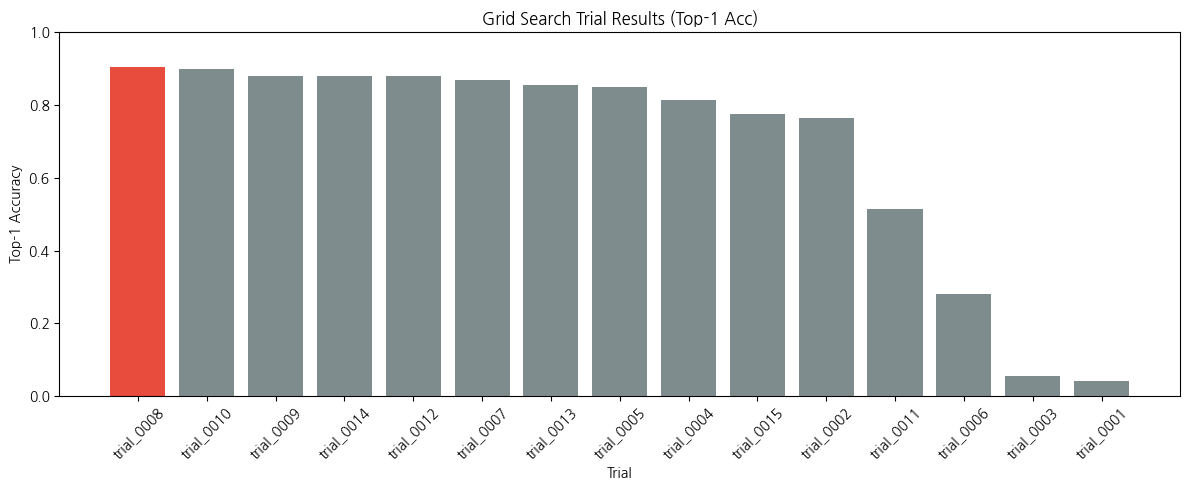


최적 Trial: trial_0008
Top-1 Acc : 0.9041
Params    : {"train.label_smoothing": 0.06951108846744834, "train.lr0": 0.0006449494922419099, "train.lrf": 0.09057492426673854, "train.weight_decay": 0.010133792664243397}


In [31]:
# ── Grid Search 시각화 ─────────────────────────────────────────────────
# [변경] Optuna 시각화 → Grid Search 시각화로 전환
# [원본 Optuna 코드는 하단에 주석으로 보존]

if TUNING_METHOD != "optuna":
    print("Grid Search 모드에서만 사용 가능합니다.")
else:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams['axes.unicode_minus'] = False

    results_csv = TUNING_OUTPUT / "results.csv"
    if not results_csv.exists():
        print("results.csv 없음 — HPO 실행 후 다시 시도하세요.")
    else:
        df = pd.read_csv(results_csv)
        df_ok = df[df["status"] == "ok"].copy()
        df_ok["score"] = pd.to_numeric(df_ok["score"], errors="coerce")
        df_ok["elapsed_min"] = (pd.to_numeric(df_ok["elapsed_sec"], errors="coerce") / 60).round(1)
        df_sorted = df_ok.sort_values("score", ascending=False).reset_index(drop=True)

        # Top-1 Acc 막대 그래프
        fig, ax = plt.subplots(figsize=(12, 5))
        colors = ["#E74C3C" if i == 0 else "#7F8C8D" for i in range(len(df_sorted))]
        ax.bar(df_sorted["trial"], df_sorted["score"], color=colors)
        ax.set_xlabel("Trial")
        ax.set_ylabel("Top-1 Accuracy")
        ax.set_title("Grid Search Trial Results (Top-1 Acc)")
        ax.set_ylim(0, 1)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 최적 trial 출력
        best = df_sorted.iloc[0]
        print(f"\n최적 Trial: {best['trial']}")
        print(f"Top-1 Acc : {best['score']:.4f}")
        print(f"Params    : {best['params']}")

# ── [보존] 원본 Optuna 시각화 코드 ────────────────────────────────────
# try:
#     import optuna
#     import optuna.visualization as vis
#     from IPython.display import display
#
#     storage = f"sqlite:///{TUNING_OUTPUT / 'study.db'}"
#     study = optuna.load_study(study_name="stage2_optuna", storage=storage)
#
#     print(f"완료 trial 수: {len(study.trials)}")
#     print(f"최적 trial  : trial_{study.best_trial.number:04d}  "
#           f"{TUNING_METRIC}={study.best_value:.4f}")
#     print(f"최적 params : {study.best_params}")
#
#     fig_imp = vis.plot_param_importances(study)
#     fig_imp.show()
#     fig_hist = vis.plot_optimization_history(study)
#     fig_hist.show()
#     fig_cont = vis.plot_contour(study)
#     fig_cont.show()
#
# except ModuleNotFoundError:
#     print("optuna 미설치: pip install optuna plotly")
# except Exception as e:
#     print(f"시각화 오류: {e}")

## 6. 최적 Trial Config 추출

`best_trial.json` 구조

```
# Optuna
{ "number": 7, "value": 0.923, "params": {"train.lr0": 0.0001, ...}, "user_attrs": {...} }

# Grid Search
{ "trial": "trial_0003", "score": 0.915, "top1_acc": 0.915, "params": "{...}" }
```

최적 파라미터를 `s2_config.yaml`에 덮어써서 `EXP_DIR/s2_best_config.yaml`로 저장합니다.  
이후 Stage 2 재학습 시 `--config` 인자에 이 파일을 지정하세요.


In [32]:
best_json = TUNING_OUTPUT / "best_trial.json"

if not best_json.exists():
    print("best_trial.json 없음 — HPO 실행 후 다시 시도하세요.")
else:
    with open(best_json, encoding="utf-8") as f:
        best = json.load(f)

    print("=== 최적 Trial ===")
    # [변경] Grid Search / Optuna 구조 분기 수정
    # Grid Search best_trial.json: { "trial": "trial_0007", "score": 0.8362, "params": "{...}" }
    # Optuna best_trial.json     : { "number": 7, "value": 0.923, "params": {...} }
    if TUNING_METHOD == "optuna":
        print(f"trial    : {best['trial']}")
        print(f"score    : {best['score']:.4f}")
        best_params = json.loads(best["params"])
    else:
        # [보존] 원본 Optuna 코드
        # print(f"trial    : trial_{best['number']:04d}")
        # print(f"score    : {best['value']:.4f}")
        # best_params = best["params"]
        print(f"trial    : trial_{best['number']:04d}")
        print(f"score    : {best['value']:.4f}")
        best_params = best["params"]

    print(f"params   : {best_params}")

    # 최적 config를 EXP_DIR/s2_best_config.yaml 로 저장
    with open(S2_CONFIG, encoding="utf-8") as f:
        base_cfg = yaml.safe_load(f)

    for dotted_key, value in best_params.items():
        cur = base_cfg
        parts = dotted_key.split(".")
        for part in parts[:-1]:
            cur = cur.setdefault(part, {})
        cur[parts[-1]] = value

    out_cfg = EXP_DIR / "s2_best_config.yaml"
    with open(out_cfg, "w", encoding="utf-8") as f:
        yaml.safe_dump(base_cfg, f, sort_keys=False, allow_unicode=True)
    print(f"\n최적 config 저장 → {out_cfg}")

=== 최적 Trial ===
trial    : trial_0009
score    : 0.8786
params   : {'train.label_smoothing': 0.05, 'train.lr0': 0.0003, 'train.weight_decay': 0.001}

최적 config 저장 → /content/codeit-part2-2team-project/experiments/exp_20260420_baseline_yolo26n/s2_best_config.yaml


## 7. 소요 시간 요약

trial당 소요 시간과 전체 탐색 시간을 집계합니다.  
다음 탐색 계획(trial 수, epoch 수) 결정에 참고하세요.


trial 수      : 15
trial 평균    : 3648.7초  (60.8분)
전체 소요     : 54730.5초  (15.2시간)


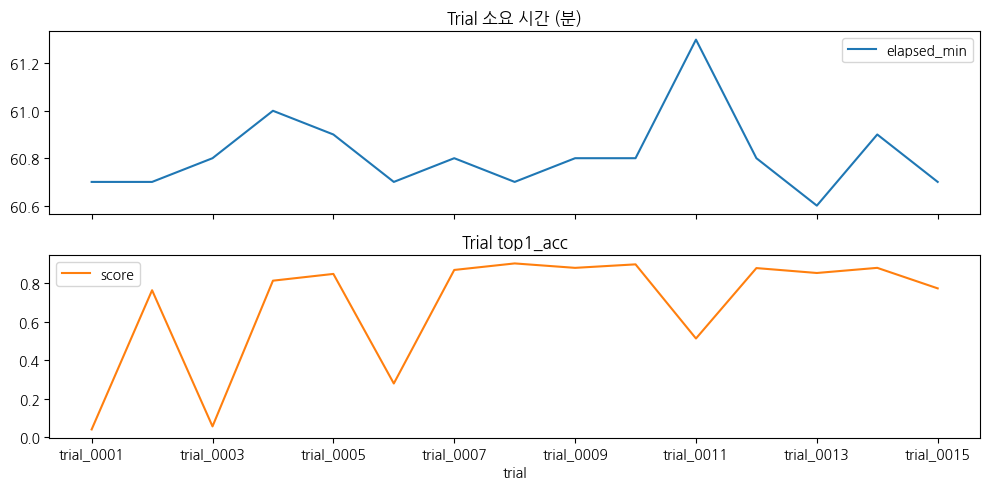

In [33]:
# ── 소요 시간 분포 확인 ────────────────────────────────────────────────
# Grid Search / Optuna 공통 사용 가능

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df_ok = df[df["status"] == "ok"].copy()
    df_ok["elapsed_sec"] = pd.to_numeric(df_ok["elapsed_sec"], errors="coerce")

    total_sec = df_ok["elapsed_sec"].sum()
    mean_sec  = df_ok["elapsed_sec"].mean()
    print(f"trial 수      : {len(df_ok)}")
    print(f"trial 평균    : {mean_sec:.1f}초  ({mean_sec/60:.1f}분)")
    print(f"전체 소요     : {total_sec:.1f}초  ({total_sec/3600:.1f}시간)")

    df_ok["elapsed_min"] = (df_ok["elapsed_sec"] / 60).round(1)
    df_ok[["trial", "elapsed_min", "score"]].sort_values("trial").plot(
        x="trial", y=["elapsed_min", "score"], subplots=True, figsize=(10, 5),
        title=["Trial 소요 시간 (분)", f"Trial {TUNING_METRIC}"]
    )
    import matplotlib.pyplot as plt
    plt.tight_layout()
    plt.show()